# Project 4

## Question

What is the most optimal skill to learn for Data Analysts?

### Methodology

1. Group skills to determine median salary and likelihood of being in job postings.
2. Visualize median salary vs percentage of job postings.
3. Determine which skills provide the best combination of demand and salary.

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [11]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

df_DA_US = df_DA_US.dropna(subset="salary_year_avg")

df_DA_US_exploded = df_DA_US.explode("job_skills")

df_DA_US_exploded[["salary_year_avg", "job_skills"]].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [24]:
df_DA_skills = df_DA_US_exploded.groupby("job_skills")["salary_year_avg"].agg(["count","median"]).sort_values(by="count", ascending=False)
df_DA_skills = df_DA_skills.rename(columns = {"count" : "skill_count", "median" : "median_salary"})

df_job_count = len(df_DA_US)

df_DA_skills["skill_perc"] = df_DA_skills["skill_count"] / df_job_count * 100

skill_perc = 5


df_DA_skills_high_demand = df_DA_skills[df_DA_skills["skill_perc"] > skill_perc]


df_DA_skills_high_demand

,skill_count,median_salary,skill_perc
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


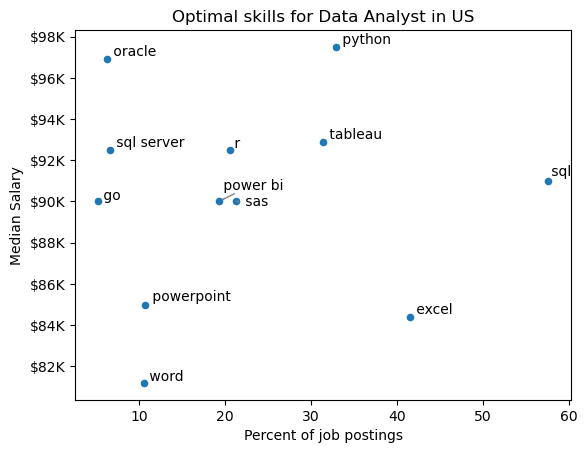

In [37]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind="scatter", x="skill_perc", y="median_salary")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

text = []

for i,txt in enumerate(df_DA_skills_high_demand.index):
    text.append(plt.text(df_DA_skills_high_demand["skill_perc"].iloc[i], df_DA_skills_high_demand["median_salary"].iloc[i], " " + txt))

adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel("Percent of job postings")
plt.ylabel("Median Salary")
plt.title("Optimal skills for Data Analyst in US")
plt.show()